[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8432.23it/s]


[{'label': 'POSITIVE', 'score': 0.999884843826294}]
API error on 2026-07-23 to 2026-07-26, page 2: maximumResultsReached - You have requested too many results. Developer accounts are limited to a max of 100 results. You are trying to request results 100 to 200. Please upgrade to a paid plan if you need more results.
Total articles fetched: 100
["Morning Bid: Magnificent cash burn July 23 (Reuters) - What matters in U. and global markets today, Editor-at-Large, Finance and Markets There was a familiar playbook in response to Alphabet'...", "Mbanq secures inaugural institutional funding investment The programme, recently listed on the Düsseldorf Stock Exchange, supports the expansion of the company's lending and Earned Wage Access platform", 'Alphabet flops, Intel shocks, and Tesla tanks: AlphaSpace weekly recap Some markets observations, compliments of Yahoo Finance AlphaSpace.', 'Top 3 US Stock Market Stories From This Week Top US stock market stories this week: Tesla’s drop, $100 oil 

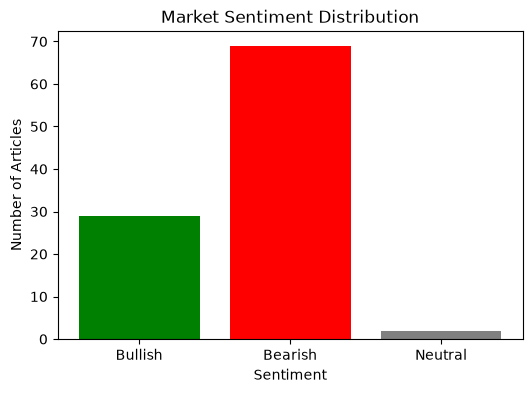

In [29]:
from transformers import pipeline
model = pipeline("sentiment-analysis")
print(model("I love this project"))
import requests
from datetime import datetime, timedelta
API_KEY = "8afa2742ee464a1493576c11d7f68e02"
url = "https://newsapi.org/v2/everything"
# Query parameters
query = "finance AND (stock market OR investment)"
language = "en"
page_size = 100  # max per request
# Date range setup: last 30 days
end_date = datetime.today()
start_date = end_date - timedelta(days=30)
all_articles = []
# Split the 30-day range into 3-day chunks (adjust as needed)
delta = timedelta(days=3)
current_start = start_date
stop_all = False  # used to break out of both loops if we hit a hard API error
while current_start < end_date and not stop_all:
    current_end = min(current_start + delta, end_date)
    page = 1
    while True:
        params = {
            "q": query,
            "language": language,
            "pageSize": page_size,
            "page": page,
            "from": current_start.strftime("%Y-%m-%d"),
            "to": current_end.strftime("%Y-%m-%d"),
            "apiKey": API_KEY,
        }
        response = requests.get(url, params=params)
        data = response.json()
        # Check for API-level errors (rate limit, bad key, plan restrictions, etc.)
        if data.get("status") != "ok":
            print(
                f"API error on {current_start.date()} to {current_end.date()}, "
                f"page {page}: {data.get('code')} - {data.get('message')}"
            )
            stop_all = True
            break
        articles = data.get("articles", [])
        if articles:
            all_articles.extend(articles)
            if len(articles) < page_size:
                break  # no more pages for this date range
            page += 1
        else:
            break  # no articles for this page/date range
    current_start += delta
# Extract text, safely handling missing/None descriptions
news_list = []
for article in all_articles:
    title = article.get("title") or ""
    description = article.get("description") or ""
    text = f"{title} {description}".strip()
    news_list.append(text)
print(f"Total articles fetched: {len(news_list)}")
print(news_list[:10])
results = model(news_list, truncation=True, max_length=512)
# Assuming 'results' is the output of sentiment_model(news_list)
# Map scores to labels
score_map = {"POSITIVE": "Bullish", "NEGATIVE": "Bearish"}
# Count occurrences
sentiment_counts = {"Bullish": 0, "Bearish": 0, "Neutral": 0}
for r in results:
    label = r['label']
    score = r['score']
    # Optional: set a threshold for Neutral
    if score < 0.6:
        sentiment_counts["Neutral"] += 1
    else:
        sentiment_counts[score_map[label]] += 1
print(sentiment_counts)

# --- Unique JSON file for File 1 ---
import json
with open("results_file1.json", "w") as f:
    json.dump(sentiment_counts, f, indent=4)
with open("results.json", "w") as f:
    json.dump(sentiment_counts, f, indent=4)

import matplotlib.pyplot as plt
labels = list(sentiment_counts.keys())
counts = list(sentiment_counts.values())
plt.figure(figsize=(6,4))
plt.bar(labels, counts, color=['green', 'red', 'gray'])
plt.title("Market Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Articles")
plt.show()